## Montar Drive

In [187]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [188]:
path = '/content/drive/MyDrive/Meli_Case'

In [189]:
import sys
sys.path.append(path)

## Funções

In [434]:
def plot_roc_curves(y_test, y_probs_test, y_val, y_probs_val):

    fpr_test, tpr_test, _ = roc_curve(y_test, y_probs_test)
    roc_auc_test = roc_auc_score(y_test, y_probs_test)

    fpr_val, tpr_val, _ = roc_curve(y_val, y_probs_val)
    roc_auc_val = roc_auc_score(y_val, y_probs_val)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_test, tpr_test, label=f'Teste (AUC = {roc_auc_test:.2f})')
    plt.plot(fpr_val, tpr_val, label=f'Validação (AUC = {roc_auc_val:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()

In [406]:
def encontrar_threshold_max_lucro(y_true, y_prob, montos, thresholds=np.linspace(0.01, 0.99, 100)):
    lucros = []

    y_true = y_true.values

    for t in thresholds:
        y_pred = (y_prob > t).astype(int)

        lucro_total = np.sum([
            +0.25 * m if (yt == 0 and yp == 0) else   # Legítimas aprovadas
            -0.25 * m if (yt == 0 and yp == 1) else   # Legítimas bloqueadas
            -1.00 * m if (yt == 1 and yp == 0) else   # Fraudes aprovadas
            +1.00 * m if (yt == 1 and yp == 1) else 0 # Fraudes detectadas
            for yt, yp, m in zip(y_true, y_pred, montos)
        ])

        lucros.append(lucro_total)

    melhor_threshold = thresholds[np.argmax(lucros)]
    lucro_maximo = max(lucros)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, lucros)
    plt.xlabel("Threshold")
    plt.ylabel("Lucro total")
    plt.title("Lucro vs Threshold")
    plt.axvline(melhor_threshold, color='red', linestyle='--', label=f"Melhor Threshold = {melhor_threshold:.2f}")
    plt.grid(True)
    plt.legend()
    plt.show()

    return melhor_threshold, lucro_maximo

## Imports

In [407]:
import warnings
warnings.filterwarnings('ignore')

In [408]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp
import shap
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score, classification_report

## Base

In [409]:
base = pd.read_excel(f"{path}/fraud_dataset.xlsx")
base = base.rename(columns={col: f"var_{col}" for col in base.columns if len(col) == 1 and col.isalpha()})

In [410]:
variaveis = ["var_Q", "var_R", "var_S", 'Monto']

for col in variaveis:
    base[col] = base[col].apply(lambda x: np.nan if isinstance(x, datetime) else x)

    base[col] = base[col].astype(str).str.replace(",", "").str.replace(" ", "").replace("None", np.nan)
    base[col] = pd.to_numeric(base[col], errors='coerce')

In [411]:
base = base[base['Monto'].notna()]

In [412]:
for col in ["var_C", "var_F", "var_G"]:
    base[f"{col}_log"] = np.log1p(base[col])

In [413]:
def mapear_pais(pais):
    if pais in ['BR', 'AR', 'MX']:
        return pais
    elif pais in ['ES', 'US', 'UY']:
        return 'ES_US_UY'
    else:
        return 'OUTROS'

base['pais_agg'] = base['var_J'].apply(mapear_pais)

In [414]:
pais_agg_dummies = pd.get_dummies(base['pais_agg'], prefix='pais_agg')
pais_agg_dummies = pais_agg_dummies.astype(int)

In [415]:
base = pd.concat([base, pais_agg_dummies], axis=1)
base

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_J,...,Fraude,var_C_log,var_F_log,var_G_log,pais_agg,pais_agg_AR,pais_agg_BR,pais_agg_ES_US_UY,pais_agg_MX,pais_agg_OUTROS
0,0,10,50257.0,0,0,0.0,0.0,0,0,UY,...,1,10.824925,0.000000,0.0,ES_US_UY,0,0,1,0,0
1,0,10,29014.0,0,0,0.0,0.0,0,0,UY,...,1,10.275568,0.000000,0.0,ES_US_UY,0,0,1,0,0
2,0,7,92.0,0,1,0.0,0.0,0,1,UY,...,1,4.532599,0.000000,0.0,ES_US_UY,0,0,1,0,0
3,9,16,50269.0,0,0,0.0,0.0,0,0,UY,...,1,10.825164,0.000000,0.0,ES_US_UY,0,0,1,0,0
4,0,8,8180.0,0,0,0.0,0.0,0,0,UY,...,1,9.009570,0.000000,0.0,ES_US_UY,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16875,0,3,63302.0,0,1,0.5,0.0,0,0,BR,...,1,11.055688,0.405465,0.0,BR,0,1,0,0,0
16876,0,12,825.0,0,0,0.0,0.0,0,0,BR,...,1,6.716595,0.000000,0.0,BR,0,1,0,0,0
16877,1,3,81067.0,0,0,0.0,0.0,0,0,BR,...,1,11.303044,0.000000,0.0,BR,0,1,0,0,0
16878,0,9,398372.0,0,0,0.0,0.0,0,0,BR,...,1,12.895144,0.000000,0.0,BR,0,1,0,0,0


In [416]:
base['var_K_100'] = (base['var_K'] * 100).round()

In [417]:
drop_col = ['var_C', 'var_F', 'var_G', 'var_J', 'pais_agg', 'var_K']
base = base.drop(columns=drop_col, errors='ignore')
base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16413 entries, 0 to 16879
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   var_A              16413 non-null  int64  
 1   var_B              16413 non-null  int64  
 2   var_D              16413 non-null  int64  
 3   var_E              16413 non-null  int64  
 4   var_H              16413 non-null  int64  
 5   var_I              16413 non-null  int64  
 6   var_L              16413 non-null  int64  
 7   var_M              16413 non-null  int64  
 8   var_N              16413 non-null  int64  
 9   var_O              16413 non-null  int64  
 10  var_P              16413 non-null  int64  
 11  var_Q              16403 non-null  float64
 12  var_R              16411 non-null  float64
 13  var_S              15134 non-null  float64
 14  Monto              16413 non-null  float64
 15  Fraude             16413 non-null  int64  
 16  var_C_log          13302 no

In [418]:
# base.to_csv(f"{path}/base_processada.csv", index=False)

## Treino, Teste e Validação

In [419]:
rf_fs = ['var_S',
 'Monto',
 'var_C_log',
 'var_B',
 'pais_agg_ES_US_UY',
 'var_K_100',
 'var_P',
 'var_M',
 'var_L',
 'var_A',
 'var_E',
 'pais_agg_MX',
 'var_F_log',
 'pais_agg_AR',
 'pais_agg_BR',
 'var_Q',
 'var_D']

In [420]:
X = base[rf_fs]
y = base["Fraude"]

In [421]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y, random_state=13)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.5, stratify=y_train, random_state=13)

## Optimização de Hiperparâmetros

In [422]:
space = {
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
    'gamma': hp.uniform('gamma', 0, 5),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 5.0),
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 5.0)
}

In [423]:
def objective(params):
    params['max_depth'] = int(params['max_depth'])
    params['n_estimators'] = int(params['n_estimators'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=13,
        n_jobs=-1,
        **params
    )
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    return {'loss': -auc, 'status': STATUS_OK}

In [424]:
trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=50,
            trials=trials,
            rstate=np.random.default_rng(13))

print("Melhores hiperparâmetros:", best)

100%|██████████| 50/50 [00:20<00:00,  2.43trial/s, best loss: -0.8244325682311294]
Melhores hiperparâmetros: {'colsample_bytree': np.float64(0.8081890501342278), 'gamma': np.float64(2.0343733918564535), 'learning_rate': np.float64(0.06987810521588936), 'max_depth': np.float64(4.0), 'min_child_weight': np.float64(1.0), 'n_estimators': np.float64(250.0), 'reg_alpha': np.float64(0.05330577338559758), 'reg_lambda': np.float64(3.756652882023591), 'subsample': np.float64(0.6875166541937414)}


In [332]:
best

{'colsample_bytree': np.float64(0.7936739623353964),
 'gamma': np.float64(1.6199951785771693),
 'learning_rate': np.float64(0.08530274739313425),
 'max_depth': np.float64(4.0),
 'min_child_weight': np.float64(8.0),
 'n_estimators': np.float64(210.0),
 'reg_alpha': np.float64(4.419633127363078),
 'reg_lambda': np.float64(3.100594988383205),
 'subsample': np.float64(0.9254621630561151)}

## Modelagem

In [425]:
final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=13,
    n_jobs=-1,
    max_depth=int(best['max_depth']),
    learning_rate=best['learning_rate'],
    n_estimators=int(best['n_estimators']),
    gamma=best['gamma'],
    min_child_weight=int(best['min_child_weight']),
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda']
)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8081890501342278), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=np.float64(2.0343733918564535), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.06987810521588936), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=-1,
              num_parallel_tree=None, random_state=13, ...)

In [430]:
y_probs_test = final_model.predict_proba(X_test)[:, 1]
y_probs_val = final_model.predict_proba(X_val)[:, 1]

## Avaliação do Modelo

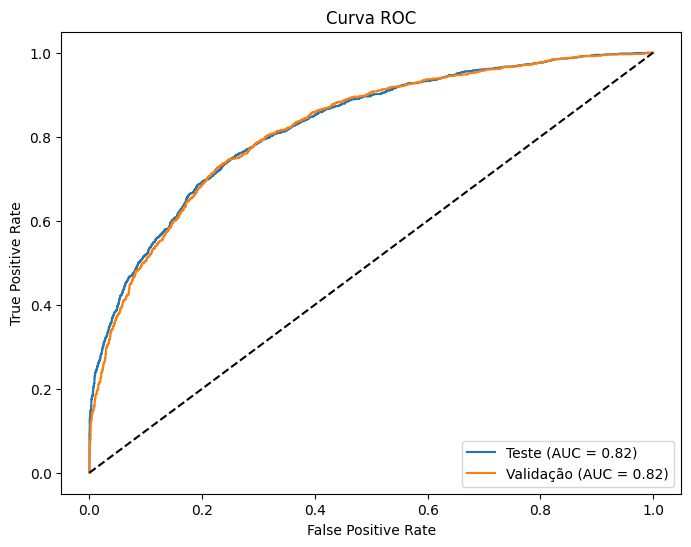

In [435]:
plot_roc_curves(y_test, y_probs_test, y_val, y_probs_val)

In [436]:
ks_test = ks_2samp(y_probs_test[y_test == 0], y_probs_test[y_test == 1]).statistic
ks_val = ks_2samp(y_probs_val[y_val == 0], y_probs_val[y_val == 1]).statistic

print(f"KS Test: {ks_test:.4f}")
print(f"KS Val: {ks_val:.4f}")

KS Test: 0.4969
KS Val: 0.5005


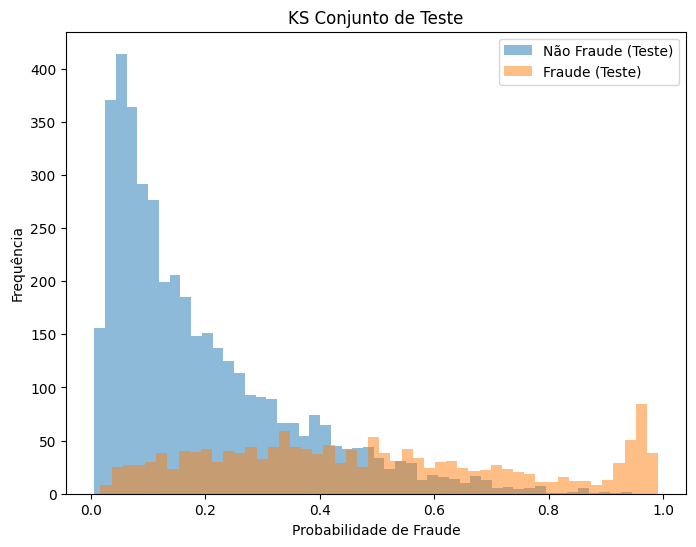

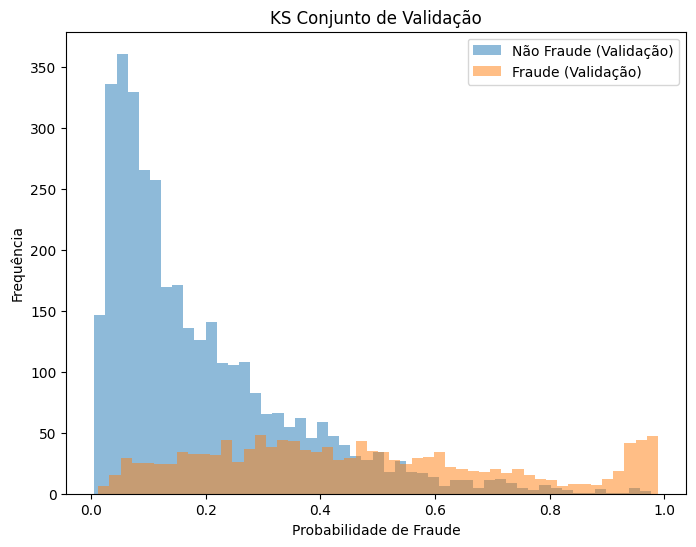

In [442]:
plt.figure(figsize=(8, 6))
plt.hist(y_probs_test[y_test == 0], bins=50, alpha=0.5, label='Não Fraude (Teste)')
plt.hist(y_probs_test[y_test == 1], bins=50, alpha=0.5, label='Fraude (Teste)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Teste')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(y_probs_val[y_val == 0], bins=50, alpha=0.5, label='Não Fraude (Validação)')
plt.hist(y_probs_val[y_val == 1], bins=50, alpha=0.5, label='Fraude (Validação)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Validação')
plt.legend()
plt.show()


In [438]:
ks_values = [ks_test, ks_val]
groups = ['Teste', 'Validação']

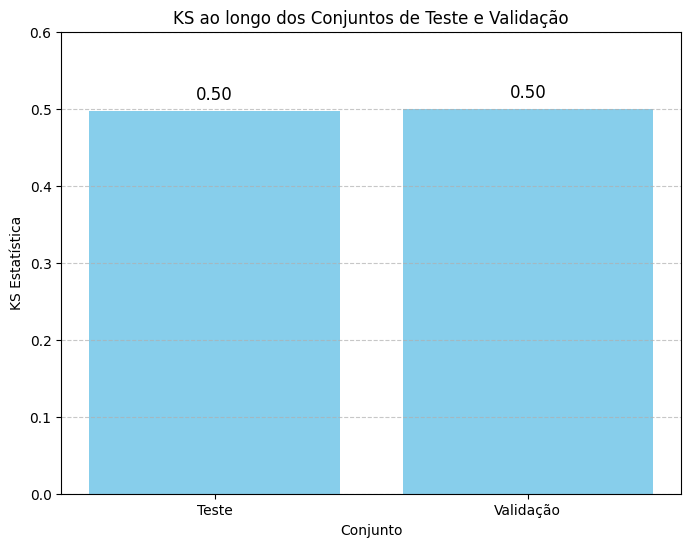

In [441]:
plt.figure(figsize=(8, 6))
bars = plt.bar(groups, ks_values, color='skyblue')
plt.xlabel("Conjunto")
plt.ylabel("KS Estatística")
plt.title("KS ao longo dos Conjuntos de Teste e Validação")
for bar, ks_val in zip(bars, ks_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{ks_val:.2f}",
             ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(ks_values) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [447]:
booster = final_model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df.sort_values(by='Importance', ascending=False, inplace=True)
importance_df

,Feature,Importance
4,pais_agg_ES_US_UY,44.982388
11,pais_agg_MX,18.860937
3,var_B,14.993090
6,var_P,6.479949
0,var_S,6.359384
7,var_M,6.190698
13,pais_agg_AR,6.097115
9,var_A,5.328260
15,var_Q,5.279974
5,var_K_100,5.144555


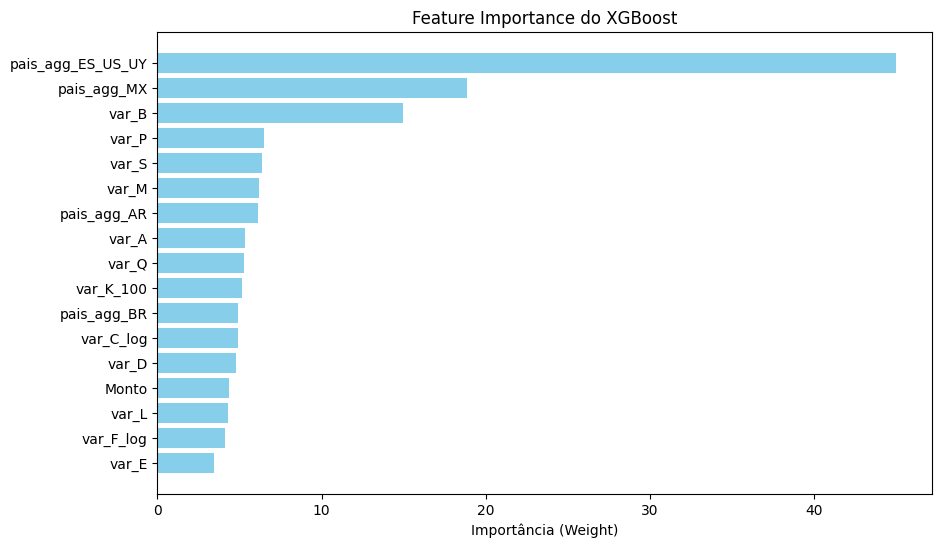

In [444]:
importance_df.sort_values(by='Importance', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Importância (Weight)")
plt.title("Feature Importance do XGBoost")
plt.show()

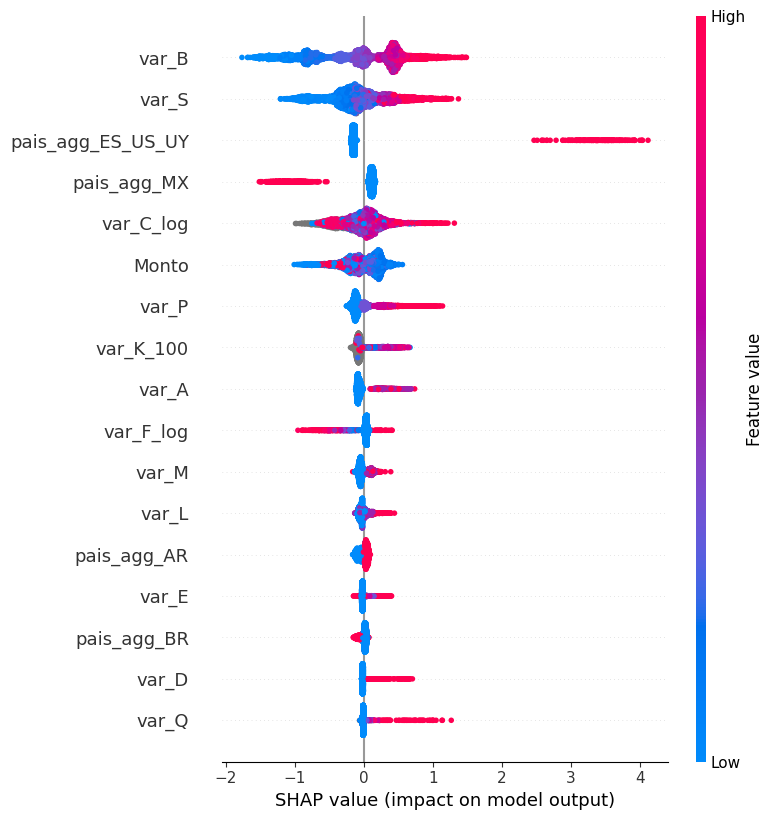

In [445]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val)

## Escolha do Threshold

In [448]:
thresholds = np.linspace(0.01, 0.99, 100)

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (y_probs_test > t).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

best_threshold_f1 = thresholds[np.argmax(f1_scores)].round(2)
print("Melhor threshold para F1-score:", best_threshold_f1)
print("F1-score correspondente:", np.max(f1_scores).round(4))

Melhor threshold para F1-score: 0.32
F1-score correspondente: 0.6241


In [449]:
for i in range(len(thresholds)):
    print(f"Threshold: {thresholds[i]:.2f}, Precision: {precisions[i]:.4f}, Recall: {recalls[i]:.4f}, F1-Score: {f1_scores[i]:.4f}")

Threshold: 0.01, Precision: 0.2742, Recall: 1.0000, F1-Score: 0.4304
Threshold: 0.02, Precision: 0.2778, Recall: 0.9994, F1-Score: 0.4347
Threshold: 0.03, Precision: 0.2858, Recall: 0.9975, F1-Score: 0.4444
Threshold: 0.04, Precision: 0.2961, Recall: 0.9937, F1-Score: 0.4563
Threshold: 0.05, Precision: 0.3056, Recall: 0.9860, F1-Score: 0.4666
Threshold: 0.06, Precision: 0.3182, Recall: 0.9746, F1-Score: 0.4798
Threshold: 0.07, Precision: 0.3302, Recall: 0.9670, F1-Score: 0.4922
Threshold: 0.08, Precision: 0.3432, Recall: 0.9600, F1-Score: 0.5056
Threshold: 0.09, Precision: 0.3538, Recall: 0.9517, F1-Score: 0.5158
Threshold: 0.10, Precision: 0.3636, Recall: 0.9384, F1-Score: 0.5241
Threshold: 0.11, Precision: 0.3749, Recall: 0.9295, F1-Score: 0.5343
Threshold: 0.12, Precision: 0.3869, Recall: 0.9206, F1-Score: 0.5448
Threshold: 0.13, Precision: 0.3944, Recall: 0.9079, F1-Score: 0.5499
Threshold: 0.14, Precision: 0.4044, Recall: 0.8997, F1-Score: 0.5580
Threshold: 0.15, Precision: 0.4143

In [451]:
# best_threshold_f1 = 0.4
best_threshold_f1

np.float64(0.32)

In [452]:
y_pred_test = (y_probs_test > best_threshold_f1).astype(int)
y_pred_val = (y_probs_val > best_threshold_f1).astype(int)

In [453]:
auc_test = roc_auc_score(y_test, y_probs_test)
f1_test = f1_score(y_test, y_pred_test)
auc_val = roc_auc_score(y_val, y_probs_val)
f1_val = f1_score(y_val, y_pred_val)

In [462]:
print("AUC (Teste):", auc_test)
print("F1-score (Teste):", f1_test)
print("AUC (validação):", auc_val)
print("F1-score (validação):", f1_val)

AUC (Teste): 0.8244325682311294
F1-score (Teste): 0.6213138686131386
AUC (validação): 0.8211114163819871
F1-score (validação): 0.6132500867152272


In [461]:
metrics = {
    'Métrica': ['AUC', 'F1-Score'],
    'Teste': [auc_test, f1_test],
    'Validação': [auc_val, f1_val]
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Métrica,Teste,Validação
0,AUC,0.824433,0.821111
1,F1-Score,0.621314,0.613250


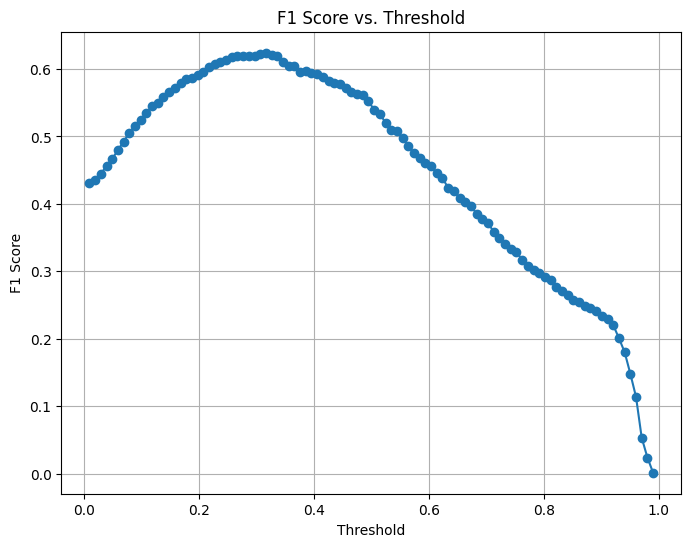

In [464]:
plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold")
plt.grid(True)
plt.show()

## Avaliação do Modelo

In [467]:
cm = confusion_matrix(y_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

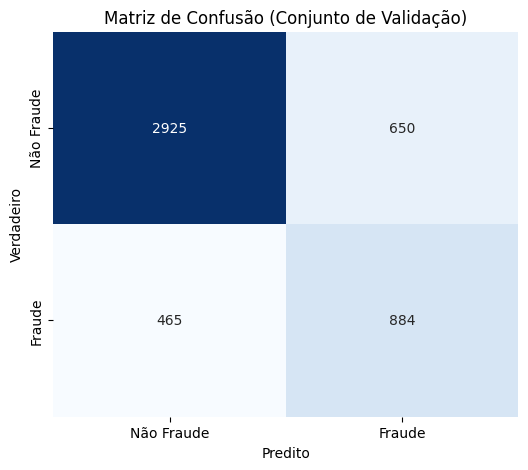

In [468]:
labels = ["Não Fraude", "Fraude"]
cm_matrix = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap="Blues", cbar=False)
plt.title('Matriz de Confusão (Conjunto de Validação)')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

In [469]:
report = classification_report(y_val, y_pred_val, target_names=["Não Fraude", "Fraude"])
print("Classification Report (Validação):\n")
print(report)

Classification Report (Validação):

              precision    recall  f1-score   support

  Não Fraude       0.86      0.82      0.84      3575
      Fraude       0.58      0.66      0.61      1349

    accuracy                           0.77      4924
   macro avg       0.72      0.74      0.73      4924
weighted avg       0.78      0.77      0.78      4924



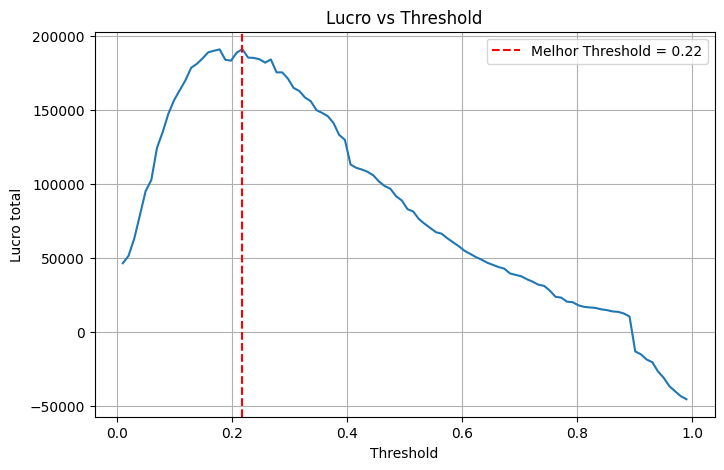

Melhor Threshold para Lucro: 0.22
Lucro Máximo: R$ 190953.00


In [490]:
montos_val = X_val['Monto']

melhor_thresh_lucro, lucro_max = encontrar_threshold_max_lucro(y_val, y_probs_val, montos_val.values)

print(f"Melhor Threshold para Lucro: {(melhor_thresh_lucro).round(2):.2f}")
print(f"Lucro Máximo: R$ {(lucro_max).round():.2f}")

In [471]:
def metricas_fraude(cm, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
    alert_rate = fp / (tp + fp) if (tp + fp) > 0 else 0
    hit_rate = tp / (tp + fp) if (tp + fp) > 0 else 0
    rejection_rate = (tp + fp) / (tp + fp + tn + fn)  # fraudes + falsos alertas

    print("📊 Métricas específicas de Fraude:")
    print(f"🔍 Detection Rate (Recall):     {detection_rate:.4f}")
    print(f"🚨 Alert Rate (False Alarm):    {alert_rate:.4f}")
    print(f"🎯 Hit Rate (Precision):        {hit_rate:.4f}")
    print(f"⛔ Rejection Rate (Alertas):    {rejection_rate:.4f}")

In [472]:
metricas_fraude(cm, y_test, y_pred_test)

📊 Métricas específicas de Fraude:
🔍 Detection Rate (Recall):     0.6756
🚨 Alert Rate (False Alarm):    0.4249
🎯 Hit Rate (Precision):        0.5751
⛔ Rejection Rate (Alertas):    0.3220


In [473]:
metricas_fraude(cm, y_val, y_pred_val)

📊 Métricas específicas de Fraude:
🔍 Detection Rate (Recall):     0.6553
🚨 Alert Rate (False Alarm):    0.4237
🎯 Hit Rate (Precision):        0.5763
⛔ Rejection Rate (Alertas):    0.3115


In [501]:
def calculate_profit(y_true, y_pred, amounts):
    amounts = amounts.loc[y_true.index]
    tp = np.sum((y_true == 1) & (y_pred == 1))  # Fraudes detectadas e bloqueadas (Somar e *(+1))
    fp = np.sum((y_true == 0) & (y_pred == 1))  # Transação Legítimas bloqueadas (Somar e *(-0,25))
    tn = np.sum((y_true == 0) & (y_pred == 0))  # Transação Legítimas Aprovadas (Somar e *0,25)
    fn = np.sum((y_true == 1) & (y_pred == 0))  # Fraudes Aprovada (Somar e *(-1))
    # Cálculo do lucro
    Lucro_Bruto = 0.25 * np.sum(amounts[(y_true == 0) & (y_pred == 0)])
    Save = np.sum(amounts[(y_true == 1) & (y_pred == 1)])
    Saldo_Neg = -0.25 * np.sum(amounts[(y_true == 0) & (y_pred == 1)]) #Dinheiro que deixamos de ganhar
    Prejuizo = -1.00 * np.sum(amounts[(y_true == 1) & (y_pred == 0)])

    print(f"Lucro: {Lucro_Bruto:.2f}")
    print(f"Prejuizo: {Prejuizo:.2f}")
    print(f"Save : {Save:.2f}") # Quanto não perdi
    print(f"Saldo Negativo: {Saldo_Neg:.2f}") #Quanto deixei passar de Fraude
    print(f"Balanço Total: {Lucro_Bruto + Prejuizo + Save + Saldo_Neg:.2f}")
    print(f"Lucro Real: {Lucro_Bruto + Prejuizo:.2f}")
    return

In [502]:
calculate_profit(y_val, y_pred_val, X_val['Monto'])

Lucro: 142104.86
Prejuizo: -84384.92
Save : 123494.50
Saldo Negativo: -20262.22
Balanço Total: 160952.22
Lucro Real: 57719.94


In [511]:
123494.50/(57719.94) # Ganhamos 2,1 vezes mais com o Save do com o que arrecadamos!

2.139546576105242

In [510]:
57719*2.14

123518.66